In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
# Set plotting parameters for figures
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

In [14]:
# Import catrace functions and load dataset configuration
from catrace.exp_collection import read_df
from catrace.dataset import load_dataset_config
dsconfig = load_dataset_config('../dataset_configs/juvenile_dataset_t7.json')

In [15]:
from catrace.exp_collection import concatenate_df_from_db
all_dff = concatenate_df_from_db(dsconfig.processed_trace_dir, dsconfig.exp_list)


2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-02-05-DpOBEM-JH9_Dp None
2021-03-18-DpOBEM-JH10_Dp None
2021-03-19-DpOBEM-JH10_Dp None
2021-04-02-DpOBEM-JH11_Dp None
2021-04-03-DpOBEM-JH11_Dp None
2021-05-01-DpOBEM-JH13_Dp None
2021-05-22-DpOBEM-JH14_Dp None
2021-09-15-DpOBEM-JH20_Dp None
2021-09-17-DpOBEM-JH20_Dp None
2021-09-18-DpOBEM-JH20_Dp None
2021-07-30-DpOBEM-JH17_Dp None
2021-07-31-DpOBEM-JH17_Dp None
2021-09-02-DpOBEM-JH18_Dp None
2021-09-03-DpOBEM-JH18_Dp None
2021-09-04-DpOBEM-JH18_Dp None
2021-09-29-DpOBEM-JH21_Dp None
2021-10-01-DpOBEM-JH21_Dp None
2021-10-02-DpOBEM-JH21_Dp None
2021-10-14-DpOBEM-JH22_Dp None
2021-11-10-DpOBEM-JH23_Dp None
2021-11-11-DpOBEM-JH23_Dp None
2021-11-14-DpOBEM-JH23_Dp None
2021-11-24-DpOBEM-JH24_Dp None
2021-11-27-DpOBEM-JH24_Dp None
2021-11-26-DpOBEM-JH24_Dp None


In [16]:
# Select some neurons that are responsive to both odors
cut_time = 2.3 # The traces showed be shifted to the left by 2.3s, so that the odor onset is approximately 2s
cut_frame = int(cut_time * dsconfig.frame_rate)
begin_time = cut_time +0
begin_frame = int(begin_time * dsconfig.frame_rate)
total_time = 12 # Total time to plot, 10s
total_frame = int(total_time * dsconfig.frame_rate)
frame_range = (begin_frame, begin_frame + total_frame) # Frame range to select from the saved firing rate dataframe

# Select the frames
from catrace.process_time_trace import select_time_points
dff = select_time_points(all_dff, frame_range)






In [17]:
import pandas as pd
import os
file_path = os.path.join(dsconfig.results_dir, 'offset_responsive_cluster')
# Read saved pickle file
matched_label_df = pd.read_pickle(os.path.join(file_path, 'matched_cluster_labels.pkl'))


In [18]:
import numpy as np

def plot_cluster_mean(mean_firing_rate, color_cycle=None):
    # Plot mean firing rate for each cluster
    fig, ax = plt.subplots(figsize=(3, 3))
    if color_cycle is not None:
        ax.set_prop_cycle(color=color_cycle)
    for cluster in mean_firing_rate.columns:
        ax.plot(mean_firing_rate.index.get_level_values('time'), mean_firing_rate[cluster], label=f'Cluster {cluster}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Mean Z-scored firing rate')
    ax.legend()
    return fig, ax

In [19]:
def append_cluster_labels_to_dff(dff, labels):
    # columns of dff and rows of labels are the same, so add labels as a new level to the columns of dff
    dff.columns = pd.MultiIndex.from_arrays(
        [labels] + [dff.columns.get_level_values(i) for i in range(dff.columns.nlevels)],
        names=['cluster'] + list(dff.columns.names)
    )
    return dff

C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:63: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:63: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()


(0.17303000341713753, 2.725402298123443)
(0.3, 3.72)


C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:63: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:63: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()


(0.3, 3.72)
(0.3, 3.72)


C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:63: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:63: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()


...

(0.3, 3.72)
(0.3, 3.72)


C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:63: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:63: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()


(0.3, 3.72)
(0.3, 3.72)


C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:63: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:63: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()


(0.3, 3.72)
(0.3, 3.72)


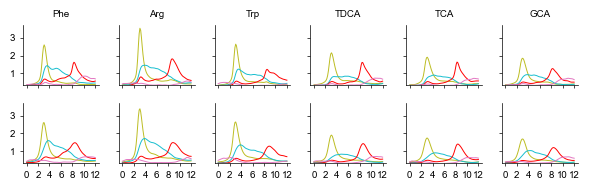

In [20]:
from catrace.process_time_trace import select_odors_df

def extract_dff_odor(dff, odor):
    dff_odor = select_odors_df(dff, [odor])
    dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
    return dff_odor

import os
paper_fig_root_dir = '../../figures_for_paper'
dataset_name = 'juvenile'
paper_fig_dir = os.path.join(paper_fig_root_dir, dataset_name, 'offset_cluster_mean')
os.makedirs(paper_fig_dir, exist_ok=True)
from catrace.for_paper import save_figure_for_paper

import seaborn as sns
import matplotlib.pyplot as plt
def plot_cluster_mean_for_paper(mean_firing_rate, color_cycle=None, ax=None):
    # Plot mean firing rate for each cluster
    if ax is None:
        fig, ax = plt.subplots(figsize=(1.24, 1.1))
    else:
        fig = ax.get_figure()
    if color_cycle is not None:
        ax.set_prop_cycle(color=color_cycle)
    time_vec = np.arange(mean_firing_rate.shape[0]) / dsconfig.frame_rate
    for cluster in mean_firing_rate.columns:
        ax.plot(time_vec, mean_firing_rate[cluster], label=f'Cluster {cluster}', linewidth=0.7)
    #ax.set_xlabel('Time (s)', fontsize=7)
    #ax.set_ylabel('Z-scored firing rate', fontsize=7)
    # Set tick label font size to 7
    ax.tick_params(axis='both', which='major', labelsize=7)
    # ax.legend(fontsize=7)
    # Set x tick interval of 2s
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(2))
    sns.despine(ax=ax)
    return fig, ax



#color_cycle = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
color_cycle = ["tab:olive", "tab:cyan", "red", "tab:pink"]
odors = dsconfig.odors_stimuli
#odors = ['Arg']
ylim = [0.3, 3.72]
conditions = ['naive', 'trained']

# Plot each odor and condition in a subplot, with condition in rows and odors in columns
fig, axes = plt.subplots(len(conditions), len(odors), figsize=(len(odors)*1.0, len(conditions)*1.0), sharex=True, sharey=True)

mean_firing_rate_dict_dict = {}
for odor in odors:
    dff_odor = extract_dff_odor(dff, odor)
    labels = matched_label_df[odor]
    dff_odor_with_labels = append_cluster_labels_to_dff(dff_odor, labels)
    mean_firing_rate_dict = {}
    for condition in conditions:
        if condition == 'naive':
            dff_odor_condition = dff_odor_with_labels.xs(condition, level='condition', axis=1)
        else:
            # Select columns when condition is not naive
            dff_odor_condition = dff_odor_with_labels.loc[:, dff_odor_with_labels.columns.get_level_values('condition') != 'naive']
        mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()
        mean_firing_rate_dict[condition] = mean_firing_rate
        ax = axes[conditions.index(condition), odors.index(odor)]
        fig, ax = plot_cluster_mean_for_paper(mean_firing_rate, color_cycle= color_cycle, ax=ax)
        # Print current ylim
        print(f'{ax.get_ylim()}')
        if condition == 'naive':
            ax.set_title(f'{odor}', fontsize=7)
        ax.set_ylim(ylim)
        # Decrease the length of the ticks on x-axis and y-axis
        ax.tick_params(axis='x', which='major', length=2)
        ax.tick_params(axis='y', which='major', length=2)
    mean_firing_rate_dict_dict[odor] = mean_firing_rate_dict
plt.tight_layout()

fig_name = f'offset_cluster_mean'
save_figure_for_paper(fig, fig_name, paper_fig_dir)
# Save fig as pdf
fig_path = os.path.join(paper_fig_dir, f'{fig_name}.pdf')
fig.savefig(fig_path, format='pdf')

In [21]:
# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure04')
os.makedirs(save_dir, exist_ok=True)

for condition in ['naive', 'trained']:
    # For condition naive, concatenate mean_firing_rate for all odors
    cond_mean_firing_rate_concat = pd.concat([mean_firing_rate_dict_dict[odor][condition] for odor in odors], axis=0)

    # Rename index level 'time' to 'frame'
    cond_mean_firing_rate_concat.index = cond_mean_firing_rate_concat.index.set_names('frame', level='time')

    time_vec = cond_mean_firing_rate_concat.index.get_level_values('frame') / dsconfig.frame_rate - 2.3
    # Append time_vec as new level in index
    cond_mean_firing_rate_concat.index = pd.MultiIndex.from_arrays([time_vec] + [cond_mean_firing_rate_concat.index.get_level_values(i) for i in range(cond_mean_firing_rate_concat.index.nlevels)], names=['time'] + list(cond_mean_firing_rate_concat.index.names))

    # Reorder levels to odor, time, frame
    cond_mean_firing_rate_concat = cond_mean_firing_rate_concat.reorder_levels(['odor', 'time', 'frame'])

    # Save cond_mean_firing_rate_concat as csv
    cond_mean_firing_rate_concat.to_csv(os.path.join(save_dir, f'extended_figure04d_offset_responsive_cluster_firing_rate_{condition}.csv'))

C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\3924557031.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\3924557031.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()


(0.17303000341713753, 2.725402298123443)
(0.2179028476470937, 2.723997299150018)


C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\3924557031.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\3924557031.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()


(0.12193255974891923, 3.717660043512403)
(0.15708506984215753, 3.5600326664521074)


C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\3924557031.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\3924557031.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()


...

(0.1659986348815573, 2.2526590274731118)
(0.22973575768685778, 1.9873146583507715)


C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\3924557031.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\3924557031.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()


(0.18063305139368546, 1.9886604213670847)
(0.22031152853753597, 1.8152513701194835)


C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\610820155.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\3924557031.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_22756\3924557031.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()


(0.21820205150253302, 1.9230020663989964)
(0.2379709196072205, 1.757493137241041)


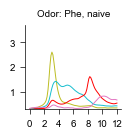

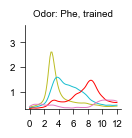

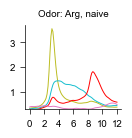

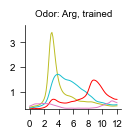

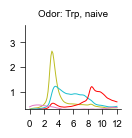

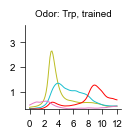

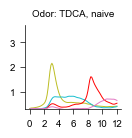

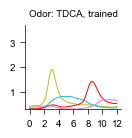

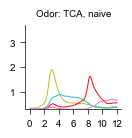

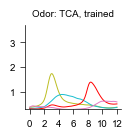

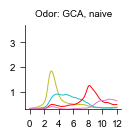

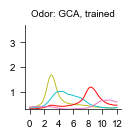

In [22]:

for odor in odors:
    dff_odor = extract_dff_odor(dff, odor)
    labels = matched_label_df[odor]
    dff_odor_with_labels = append_cluster_labels_to_dff(dff_odor, labels)
    for condition in conditions:
        if condition == 'naive':
            dff_odor_condition = dff_odor_with_labels.xs(condition, level='condition', axis=1)
        else:
            # Select columns when condition is not naive
            dff_odor_condition = dff_odor_with_labels.loc[:, dff_odor_with_labels.columns.get_level_values('condition') != 'naive']
        mean_firing_rate = dff_odor_condition.groupby(level='cluster', axis=1).mean()
        fig, ax = plot_cluster_mean_for_paper(mean_firing_rate, color_cycle= color_cycle)
        # Print current ylim
        print(f'{ax.get_ylim()}')
        ax.set_title(f'Odor: {odor}, {condition}', fontsize=7)
        ax.set_ylim(ylim)
        fig_name = f'offset_cluster_mean_{odor}_{condition}'
        #save_figure_for_paper(fig, fig_name, paper_fig_dir)